# Custom grids with regional-mom6

In this example, we'll look at how you can make and modify the grids used for your experiment. It's suggested that you do the basic example first either the rOM3 demo, or the machine agnostic one.

The `regional-mom6` package utilises [mom6_forge](https://github.com/NCAR/mom6_forge) from our collaborators at the National Centre for Atmospheric Research. The Grid, Topo and Vgrid objects you'll see in this demo are objects imported from `mom6_forge`, and fed into the `regional-mom6` experiment object. To understand more about these Grid objects, you can read the [mom6_forge documentation](https://ncar.github.io/mom6_forge/)

## Begin by importing packages and defining input directories

In [ ]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#! ADD DEV VERSIONS OF RMOM6. This won't be needed if we can get a proper environment that's available on ARE sessions on gadi
import sys
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/dev/regional-mom6')
sys.path.insert(0, '/g/data/gb02/ab8992/regional-mom6/dev/mom6_forge')
#!
import regional_mom6 as rmom6

In [8]:
def plot_grid(grid):

    step = np.max([grid.nx,grid.ny]) // 20 # Plot 20 grid lines in the dimention with the most points
    central_longitude = np.mean([grid.tlon.min(),grid.tlon.max()])

    fig = plt.figure(figsize=(10, 10))
    # ax = plt.axes(projection=ccrs.PlateCarree())
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude = central_longitude))
    # lines of constant j (along nx)
    for j in range(0, grid.ny, step):
        ax.plot(grid.tlon[j, :], grid.tlat[j, :], color='k', linewidth=0.5, transform=ccrs.PlateCarree(),alpha = 0.5)

    ax.plot(grid.tlon[-1, :], grid.tlat[-1, :], color='r', linewidth=0.9, transform=ccrs.PlateCarree(),alpha = 0.5)
    ax.plot(grid.tlon[0, :], grid.tlat[0, :], color='r', linewidth=0.9, transform=ccrs.PlateCarree(),alpha = 0.5)

    # lines of constant i (along ny)
    for i in range(0, grid.nx, step):
        ax.plot(grid.tlon[:, i], grid.tlat[:, i], color='k', linewidth=0.5, transform=ccrs.PlateCarree(),alpha = 0.5)
    ax.plot(grid.tlon[:, -1], grid.tlat[:, -1], color='r', linewidth=0.9, transform=ccrs.PlateCarree(),alpha = 0.5)
    ax.plot(grid.tlon[:, 0], grid.tlat[:, 0], color='r', linewidth=0.9, transform=ccrs.PlateCarree(),alpha = 0.5)

    ax.coastlines()
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0,alpha = 0.3)
    x_extent = [grid.tlon.min() ,grid.tlon.max()]
    y_extent = [grid.tlat.min() ,grid.tlat.max()]

    ax.set_extent([x_extent[0] - 0.2*grid.lenx, x_extent[1] + 0.2*grid.lenx,
               y_extent[0] - 0.2*grid.leny, y_extent[1] + 0.2*grid.leny],
              crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True,alpha = 0)
    gl.top_labels = False
    gl.right_labels = False
    if grid.name != None:
        ax.set_title(str(grid.name).replace("_"," "))
    ax.text(x_extent[0] - 0.1*grid.lenx,
            y_extent[0] - 0.1*grid.leny,
            f"(Only displaying every {step} grid lines)",
            transform=ccrs.PlateCarree()
            )
    return fig

## **Basic grids: Constant lat/lon spacing** 

A grid that's spaced by a constant $d\theta$ in both x and y, so that when plotted on an [equirectangular projection](https://en.wikipedia.org/wiki/Equirectangular_projection), we have nice evenly spaced squares. 

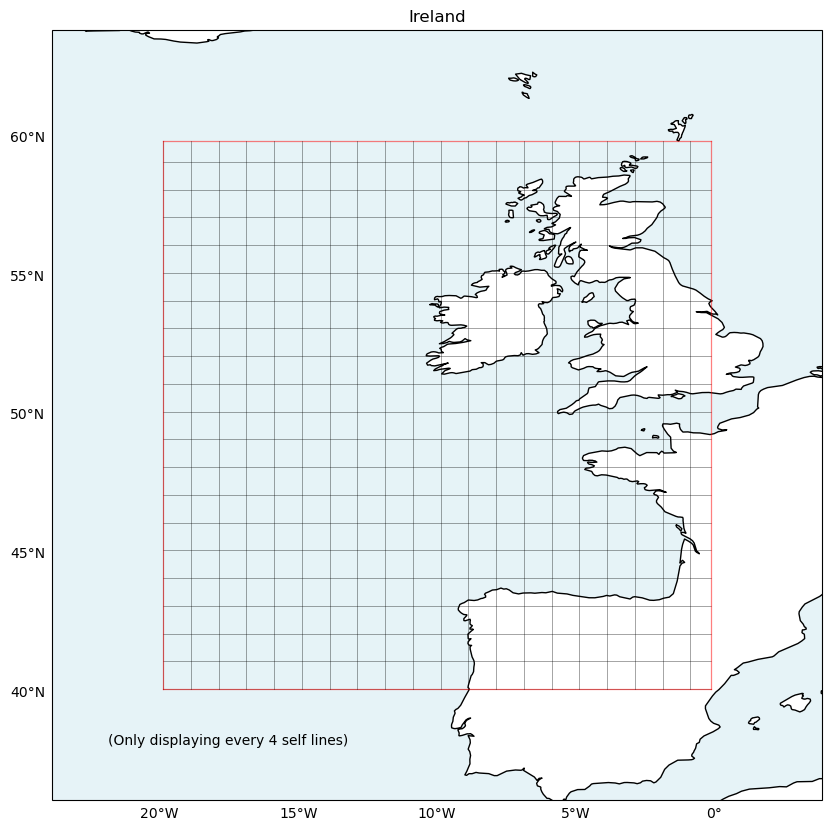

In [23]:

grid1 = rmom6.Grid(
    nx = 80,            # Number of x points
    ny = 80,            
    lenx = 20,          # Longitudinal extent of domain in degrees
    leny = 20,
    xstart = -20,       # Longitude of bottom left corner
    ystart = 40,
    name = "Ireland"    # Name is optional
    )
fig = grid1.plot()

Note that for readability, the plotting function will only plot a maximum of 20 grid points in any direction. To see what's actually going on, you can use the `tlat` and `tlon` properties, which return numpy arrays of the tracer latitude and longitudes. You can also look at the [staggered velocity grid](https://mom6.readthedocs.io/en/dev-gfdl/api/generated/pages/Discrete_Grids.html) with `.ulat` and `ulon`.

In [24]:
grid1.tlon

<xarray.DataArray (ny: 80, nx: 80)> Size: 51kB
array([[-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125],
       [-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125],
       [-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125],
       ...,
       [-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125],
       [-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125],
       [-19.875, -19.625, -19.375, ...,  -0.625,  -0.375,  -0.125]],
      shape=(80, 80))
Dimensions without coordinates: ny, nx
Attributes:
    name:     array of t-grid longitudes
    units:    degrees_east

### Cell aspect ratio

Now, the above grid looks pretty nice when plotted along lines of constant lon and lat, but if you measure them in kilometres rather than degrees it's a different story. Below, we plot the ratio of the cell with to cell height, revealing that our grid is actually made up of skinny rectangles with aspect ratios between 1/3 and 2/3



Maximum ratio between width and length		0.76
Minimum ratio between width and length		0.5


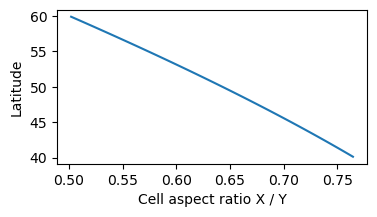

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4,2))
ratios = (grid1.dxCu / grid1.dyCu).isel(nx=0)
ax.plot(ratios,grid1.tlat.isel(nx = 0))
# ratios.plot(ax=ax[0],y = "ny")
ax.set_xlabel("Cell aspect ratio X / Y")
ax.set_ylabel("Latitude")

print(f"Maximum ratio between width and length\t\t{round(ratios.values.max(),2)}")
print(f"Minimum ratio between width and length\t\t{round(ratios.values.min(),2)}")


One way to alleviate this is to set different latitude and longitude resolutions, so that the grid spacing in latitude decreases relative to longitude closer to the poles. The grid type "rectilinear_cartesian" does this for you

Maximum ratio between width and length		1.16
Minimum ratio between width and length		0.81


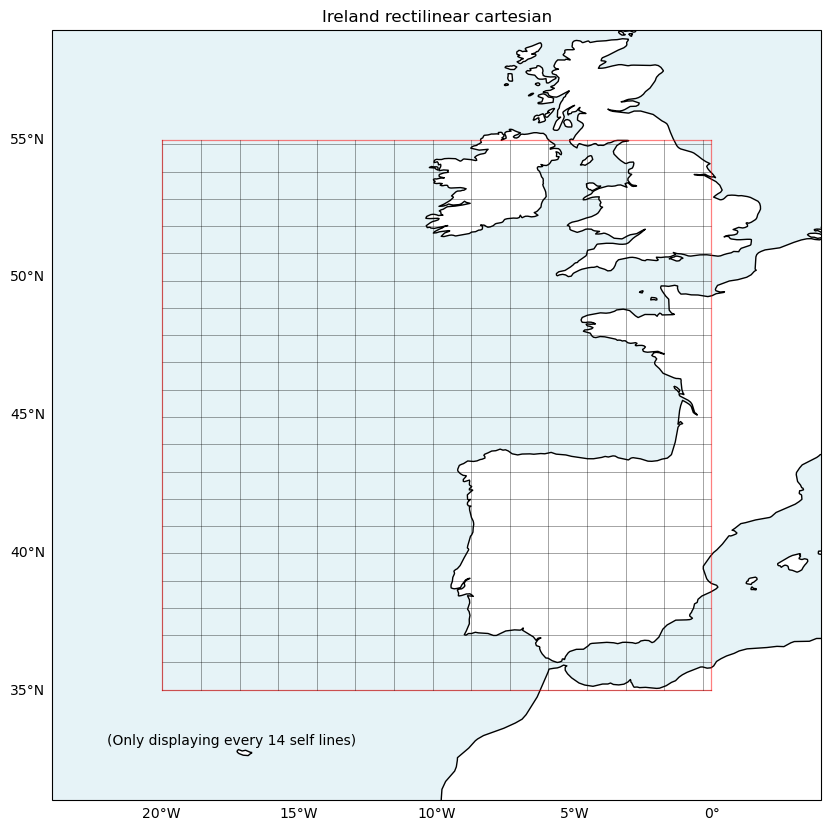

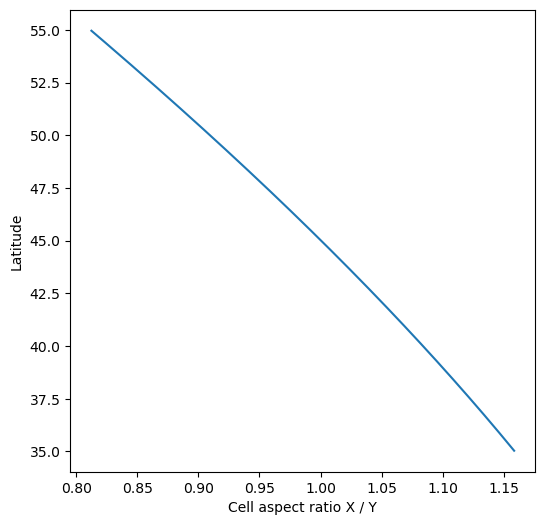

In [25]:
## Manually set a different grid spacing for latitude and longitude. Since we're so far north, a 1:2 ratio works well

# grid2 = rmom6.Grid(
#     lenx = 20,
#     leny = 20,
#     xstart = 355,
#     ystart = 50,
#     resolution_lon = 0.1,
#     resolution_lat = 0.05
#     )

## Or, scale the grid spacing automatically with `rectilinear_cartesian`, ensuring perfectly 'square' cells in the middle of the domain

grid2 = rmom6.Grid(
    lenx = 20,
    leny = 20,
    xstart = -20,
    ystart = 35,
    resolution = 0.1,
    type = "rectilinear_cartesian",
    name = "Ireland_rectilinear_cartesian"
    )


fig = grid2.plot();

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ratios = (grid2.dxt / grid2.dyt).isel(nx=0)
ax.plot(ratios,grid2.tlat.isel(nx = 0))
# ratios.plot(ax=ax[0],y = "ny")
ax.set_xlabel("Cell aspect ratio X / Y")
ax.set_ylabel("Latitude")

print(f"Maximum ratio between width and length\t\t{round(ratios.values.max(),2)}")
print(f"Minimum ratio between width and length\t\t{round(ratios.values.min(),2)}")

### Cell Area

For grids defined with constant spacing in latitude and longitude, the stretching of the grid cells with latitude also results in changes to cell area 

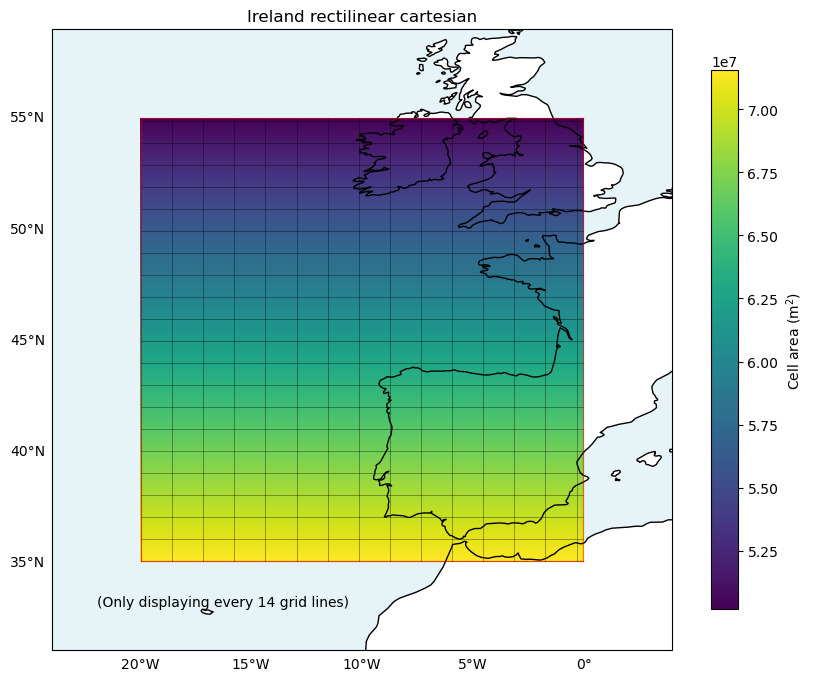

In [29]:
fig = grid2.plot()
ax = fig.axes[0]  
pcm = ax.pcolormesh(grid2.tlon, grid2.tlat, grid2.tarea, transform=ccrs.PlateCarree())
fig.colorbar(pcm, ax=ax, orientation='vertical', label='Cell area (m$^2$)', shrink=0.7)

## Pros and cons of using grids with constant lat & lon spacing

The biggest advantage of using grids with fixed spacing in both longitude and latitude is that it's simple to analyse and plot. A lot of other data products are on similar grids, making comparisons easier.


However, for calculations where areas matter, these types of grids require careful handling of area and grid spacing for each cell. Luckily, this information is encoded into the grid so you don't need to figure it out yourself.

Another disadvantage is due to the aspect ratio. The mismatch in effective latitude and longitude resolution (as measured in kilometres) means that you might have an eddy or some other phenomenon that is well resolved along one axis, but only partially along another. As the eddy moves and rotates, this can cause asymetric and non-physicsl behaviour.

## **Advanced grids: Projections**

In this section, we go through 

Maximum ratio between width and length		1.01
Minimum ratio between width and length		-3208.53


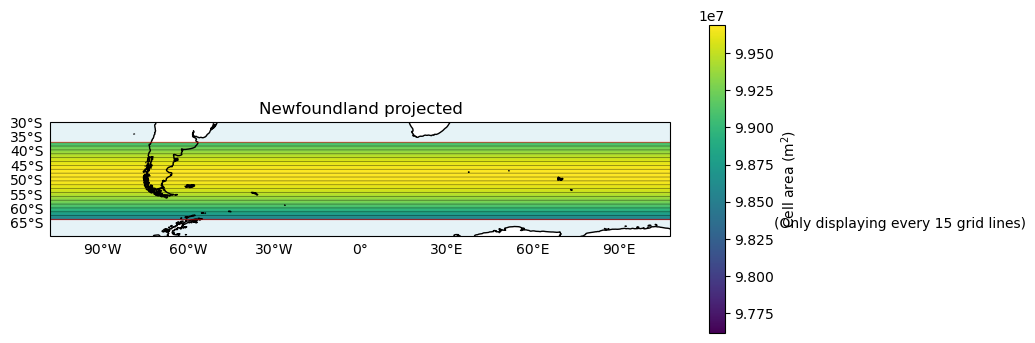

In [32]:
grid3 = rmom6.Grid.from_center(
    center_lon = 180,
    center_lat = -50,
    width_m = 3000000,
    height_m = 3000000,
    resolution_m = 10000,
    name = "Newfoundland_projected"
    
)

fig = grid3.plot()
ax = fig.axes[0]  
pcm = ax.pcolormesh(grid3.tlon, grid3.tlat, grid3.tarea, transform=ccrs.PlateCarree())
fig.colorbar(pcm, ax=ax, orientation='vertical', label='Cell area (m$^2$)', shrink=0.4)

ratios = ((grid3.dxt / grid3.dyt))

print(f"Maximum ratio between width and length\t\t{round(ratios.values.max(),2)}")
print(f"Minimum ratio between width and length\t\t{round(ratios.values.min(),2)}")

The plot above shows that while the projected grid still isn't perfectly "square" everywhere, the aspect ratio remains much closer to 1, and there is far less variance in cell area.

## Rotation

Using the same "from_center" projection, we can specify an angle of rotation. This is particularly helpful for gulfs, estuaries or following angled coastlines. 

The rotation algorithm takes a bit longer to compute due to the transformation of the whole grid

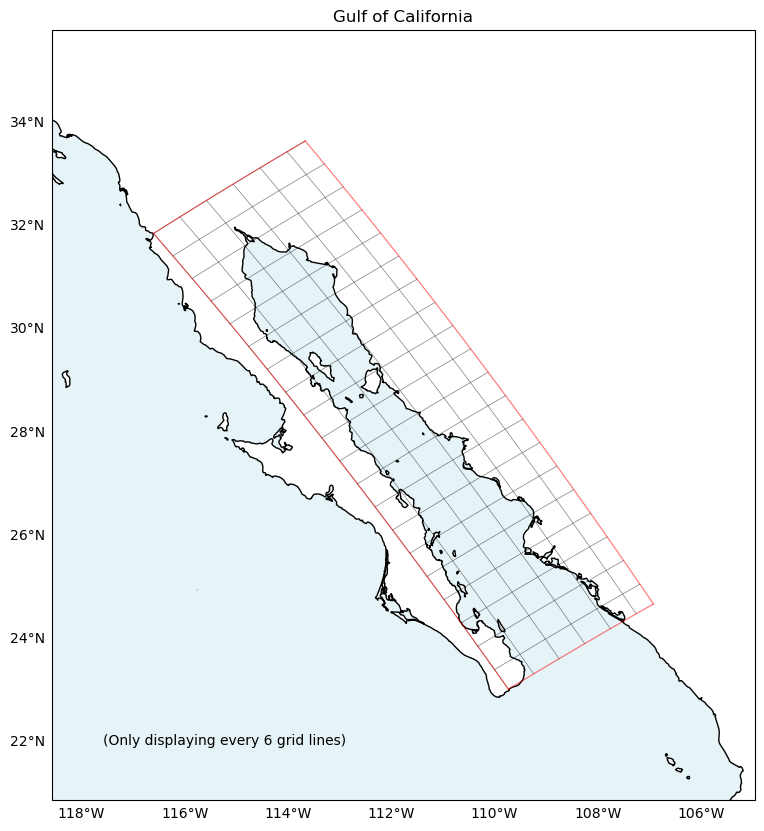

In [31]:
grid4 = rmom6.Grid.from_center(
    center_lon = -111.6,
    center_lat = 28.35,
    width_m = 1200000,
    height_m = 350000,
    resolution_m = 10000,
    angle_deg = 56,
    name = "Gulf_of_California"
)


fig = grid4.plot()

## Preset Cartopy projections



In [ ]:

grid5 = rmom6.Grid.from_projection(
    crs = "EPSG:3031",
    resolution_m = 1000,
    name = "Antarctic_Stereo",
)

plot_grid(grid5);


TypeError: Grid.from_projection() missing 4 required positional arguments: 'x_min', 'x_max', 'y_min', and 'y_max'

## Widget for grid creation

The final option is to use the interactive GridCreator tool to make your grid. This tool doesn't display well in the docs but is pretty intuitive. All the above options are supported with the widget, but for rotated and high resolution domains, the computational overhead can really slow it down. If that is the case, use the widget to find your domain and plot it at low resolution, then define it directly using one of the methods above.

In [17]:
%matplotlib ipympl
from regional_mom6.grid_creator import GridCreator
GridCreator()

GridCreator(children=(VBox(children=(VBox(children=(HTML(value='<h3>Grid Creator &mdash; Create Mode</h3>'), R…